# §1 Individual (unfiltered)

Per-combo metrics and per-combo equity/drawdown curves on the
20% OOS test partition with no ML#2 filter. Two sizing policies
compared: `fixed_dollars_500` and `pct5_compound`.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=0.0)
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Loaded 10 strategies.
results_raw cache stale; rebuilding.
Running unfiltered composed_strategy_runner for each combo...


  v10_9955...


  v5_2725...


  v9_837...


  v10_4391...


...

  Family A computed: prior_wr_10 mean=0.731, prior_wr_50 mean=0.729, has_history_50 rate=0.992
  Family A computed: prior_wr_10 mean=0.731, prior_wr_50 mean=0.729, has_history_50 rate=0.992


    n_trades=3061  rr=1.11
  v7_327...


  Family A computed: prior_wr_10 mean=0.656, prior_wr_50 mean=0.568, has_history_50 rate=0.000
  Family A computed: prior_wr_10 mean=0.656, prior_wr_50 mean=0.568, has_history_50 rate=0.000
    n_trades=14  rr=1.20
  v7_898...


  Family A computed: prior_wr_10 mean=0.657, prior_wr_50 mean=0.565, has_history_50 rate=0.000
  Family A computed: prior_wr_10 mean=0.657, prior_wr_50 mean=0.565, has_history_50 rate=0.000
    n_trades=16  rr=1.15
  v5_1097...


  Family A computed: prior_wr_10 mean=0.829, prior_wr_50 mean=0.702, has_history_50 rate=0.000
  Family A computed: prior_wr_10 mean=0.829, prior_wr_50 mean=0.702, has_history_50 rate=0.000
    n_trades=21  rr=1.48
Wrote cache -> _ml2_cache.pkl
ML2 portfolio trade counts: {'fixed_dollars_500': 119, 'pct5_compound': 119}


In [2]:
rows = []
for r in results_raw:
    if r['trades'].empty:
        for policy in POLICIES:
            rows.append({'combo_id': r['combo_id'], 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    t = r['trades'].sort_values('date', kind='mergesort')
    pnl_base = t['actual_pnl'].to_numpy(dtype=float)
    risk_base = t['dollar_risk'].to_numpy(dtype=float)
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = apply_sizing(pnl_base, risk_base, policy)
        rows.append({'combo_id': r['combo_id'], 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf1 = pd.DataFrame(rows)
perf1

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v10_9955,fixed_dollars_500,220,150.6,0.7182,7.905348e+04,1.581100e+02,8.1849,2.83,1.496170e+03
1,v10_9955,pct5_compound,220,150.6,0.7182,8.836101e+07,1.767220e+05,7.7896,14.26,1.244235e+07
2,v5_2725,fixed_dollars_500,23,15.7,0.7826,6.235380e+03,1.247000e+01,2.5328,3.59,1.980000e+03
3,v5_2725,pct5_compound,23,15.7,0.7826,4.124290e+04,8.249000e+01,2.4205,18.63,1.545005e+04
4,v9_837,fixed_dollars_500,13,8.9,0.8462,4.596590e+03,9.190000e+00,2.7911,1.93,9.957200e+02
5,v9_837,pct5_compound,13,8.9,0.8462,2.803861e+04,5.608000e+01,2.6908,9.75,5.660490e+03
6,v10_4391,fixed_dollars_500,226,154.7,0.6372,1.048723e+05,2.097400e+02,9.8419,3.10,2.101860e+03
7,v10_4391,pct5_compound,226,154.7,0.6372,1.005270e+09,2.010540e+06,9.4882,19.93,2.668765e+07
8,v10_1214,fixed_dollars_500,543,371.7,0.1786,-1.477234e+04,-2.954000e+01,-0.5251,71.08,4.431466e+04
9,v10_1214,pct5_compound,543,371.7,0.1786,-4.911258e+04,-9.823000e+01,-1.5202,99.78,1.051831e+05


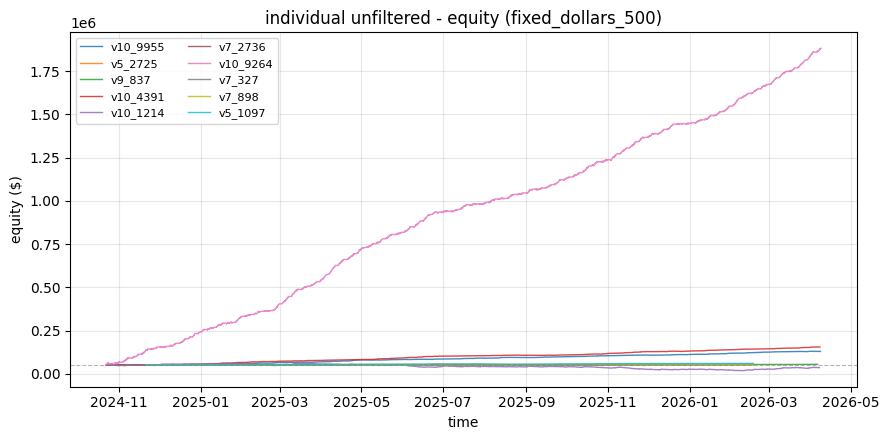

In [3]:
plot_indiv_equity(results_raw, 'fixed_dollars_500')

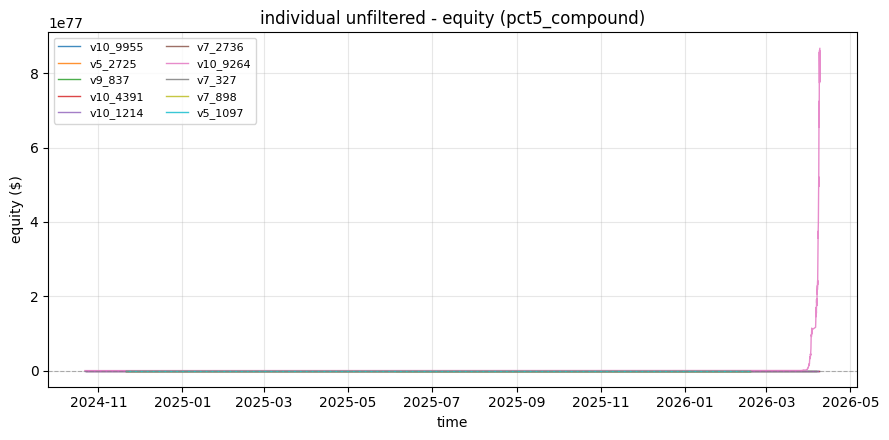

In [4]:
plot_indiv_equity(results_raw, 'pct5_compound')

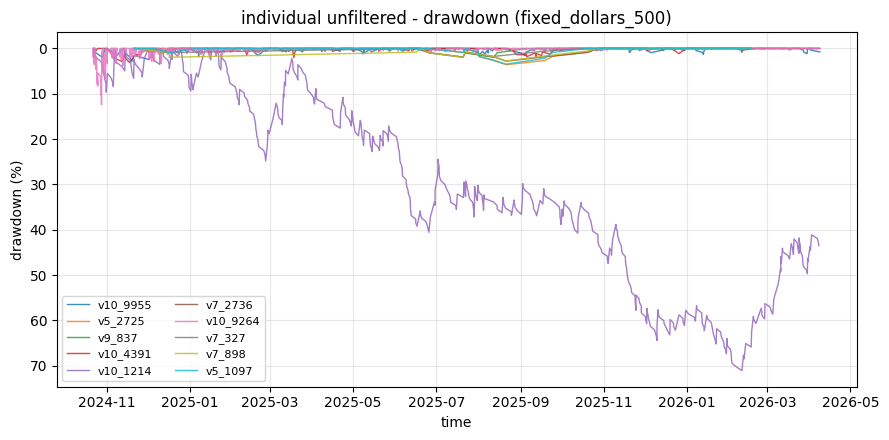

In [5]:
plot_indiv_dd(results_raw, 'fixed_dollars_500')

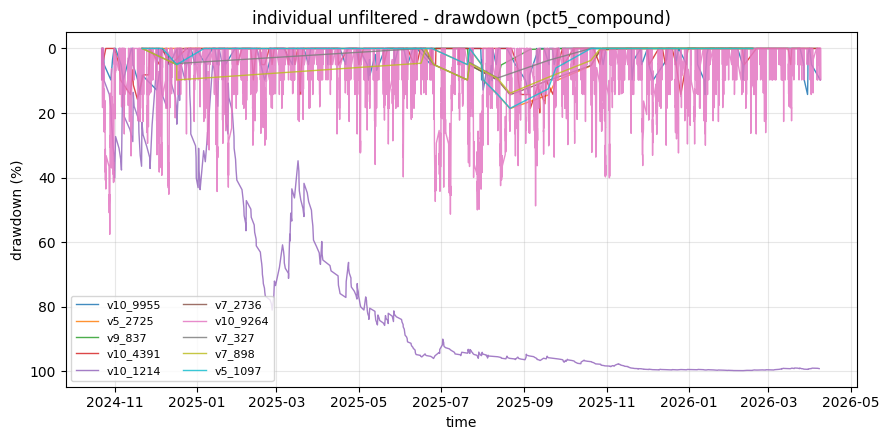

In [6]:
plot_indiv_dd(results_raw, 'pct5_compound')